# Bypass-vs-always-probe Pareto sweep plotter

Reads `sweep.csv` from a `dbspektrum_paper/results/prefer_<ts>/` run.

Emits two sets of figures next to the CSV:
1. **Throughput** — `prefer_sweep_p*.{png,pdf}` (one per payload) and `prefer_sweep.{png,pdf}` (grid).
2. **Speedup** — `prefer_sweep_p*_speedup.{png,pdf}` and `prefer_sweep_speedup.{png,pdf}`. One line per panel (`Uniform-Bypass / Uniform-Probe`) with `y = 1` as the crossover line.

CSV schema: `variant, payload, prefer_prob, natural_hit_rate, mops`.
X-axis on every plot is **Hit rate** (= `prefer_prob`, the fraction of accesses that target a page currently at its preferred frame).

In [28]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Match the paper style if present.
_style = Path('custom_plt_style.mplstyle')
if _style.exists():
    plt.style.use(str(_style))
    plt.rcParams['font.serif'] = [
        'Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'serif'
    ]

COLORS  = {'always': '#00B945', 'bypass': '#0C5DA5'}
MARKERS = {'always': 's',       'bypass': 'o'}
LABELS  = {
    'always': 'Uniform-Probe = PrediCache*',
    'bypass': 'Uniform-Bypass',
}
SPEEDUP_COLOR = '#845B97'
SPEEDUP_LABEL = 'Uniform-Bypass / Uniform-Probe'

## Configuration — point at the run you want to plot

In [29]:
# Use `.last_prefer_run` (absolute path) by default; override with a specific dir if needed.
_pointer = Path('..') / '.last_prefer_run'
if _pointer.exists():
    RUN_DIR = Path(_pointer.read_text().strip())
else:
    RUN_DIR = Path('results/prefer_merged_20260520_204305')

CSV     = RUN_DIR / 'sweep.csv'
OUTDIR  = RUN_DIR
print('reading', CSV)
print('writing plots to', OUTDIR)

reading /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/sweep.csv
writing plots to /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305


In [30]:
df = pd.read_csv(CSV).dropna(subset=['mops'])
print('rows:', len(df))
payloads = sorted(df.payload.unique())
print('payloads in this run:', payloads)
print('prefer_probs in this run:', sorted(df.prefer_prob.unique()))
df.head()

rows: 252
payloads in this run: [np.int64(0), np.int64(128), np.int64(512), np.int64(2048), np.int64(4096), np.int64(8192), np.int64(16384)]
prefer_probs in this run: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]


,variant,payload,prefer_prob,natural_hit_rate,mops
0,always,0,0.00,0.788,95.99
1,always,0,0.00,0.788,96.86
2,always,0,0.00,0.788,96.66
3,always,0,0.25,0.788,95.18
4,always,0,0.25,0.788,97.58


In [31]:
# Median + min/max across trials per (variant, payload, prefer_prob) cell.
g = (
    df.groupby(['variant', 'payload', 'prefer_prob'])
      .mops.agg(['median', 'min', 'max'])
      .reset_index()
)

# Speedup table: bypass median / always median per (payload, prefer_prob).
# Min/max-of-ratio bounded by min(bypass)/max(always) and max(bypass)/min(always).
wide = g.pivot_table(
    index=['payload', 'prefer_prob'],
    columns='variant',
    values=['median', 'min', 'max'],
)
speedup = pd.DataFrame({
    'payload':     wide.index.get_level_values('payload'),
    'prefer_prob': wide.index.get_level_values('prefer_prob'),
    'median':      wide[('median', 'bypass')].values / wide[('median', 'always')].values,
    'min':         wide[('min',    'bypass')].values / wide[('max',    'always')].values,
    'max':         wide[('max',    'bypass')].values / wide[('min',    'always')].values,
}).reset_index(drop=True)
speedup.head()

,payload,prefer_prob,median,min,max
0,0,0.00,0.889820,0.880859,0.896343
1,0,0.25,0.985558,0.970691,1.002206
2,0,0.50,1.108702,1.097358,1.119547
3,0,0.75,1.269405,1.257341,1.282444
4,0,0.90,1.378239,1.358853,1.395785


In [32]:
def title_for(payload):
    if payload == 0:
        return 'payload = 0 B (translation-only)'
    if payload >= 1024 and payload % 1024 == 0:
        return f'payload = {payload // 1024} KiB'
    return f'payload = {payload} B'

def file_tag(payload):
    if payload >= 1024 and payload % 1024 == 0:
        return f'p{payload // 1024}k'
    return f'p{payload}'

def draw_throughput_panel(ax, payload, *, show_legend=False):
    """Two lines per panel: Uniform-Probe vs Uniform-Bypass, y = Mops/s."""
    for v in ['always', 'bypass']:
        sub = g[(g.variant == v) & (g.payload == payload)].sort_values('prefer_prob')
        if sub.empty:
            continue
        ax.plot(
            sub.prefer_prob, sub['median'],
            label=LABELS[v], color=COLORS[v], marker=MARKERS[v],
            markersize=5, linewidth=1.2,
        )
        ax.fill_between(
            sub.prefer_prob, sub['min'], sub['max'],
            color=COLORS[v], alpha=0.15, linewidth=0,
        )
    ax.set_xlabel('Hit rate', fontsize=9)
    ax.set_ylabel('Throughput (Mops/s)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.tick_params(labelsize=8)
    if show_legend:
        ax.legend(loc='best', fontsize=7, frameon=False)

def draw_speedup_panel(ax, payload, *, show_legend=False):
    """Single-line panel: y = Uniform-Bypass / Uniform-Probe."""
    sub = speedup[speedup.payload == payload].sort_values('prefer_prob')
    if not sub.empty:
        ax.plot(
            sub.prefer_prob, sub['median'],
            label=SPEEDUP_LABEL, color=SPEEDUP_COLOR, marker='o',
            markersize=5, linewidth=1.2,
        )
        ax.fill_between(
            sub.prefer_prob, sub['min'], sub['max'],
            color=SPEEDUP_COLOR, alpha=0.15, linewidth=0,
        )
    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Hit rate', fontsize=9)
    ax.set_ylabel('Bypass speedup (×)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.tick_params(labelsize=8)
    if show_legend:
        ax.legend(loc='best', fontsize=7, frameon=False)

## Throughput — one stand-alone figure per payload

Files: `prefer_sweep_p<tag>.{png,pdf}` (e.g. `prefer_sweep_p0.pdf`, `prefer_sweep_p512.pdf`, `prefer_sweep_p4k.pdf`).

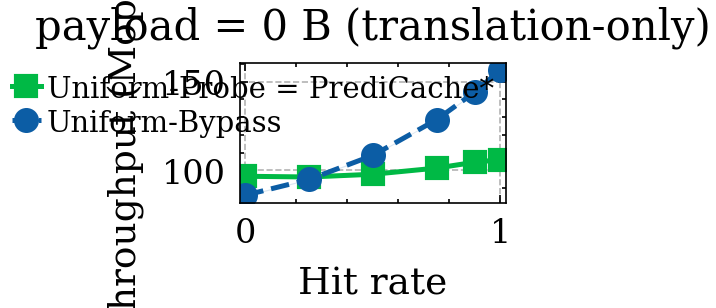

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p0.png and .pdf


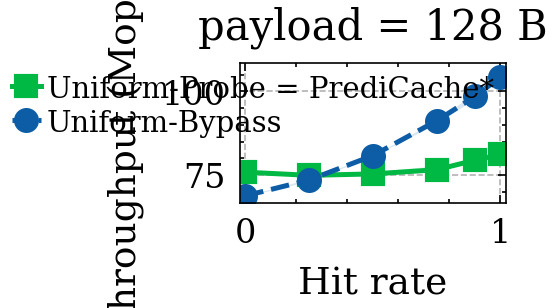

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p128.png and .pdf


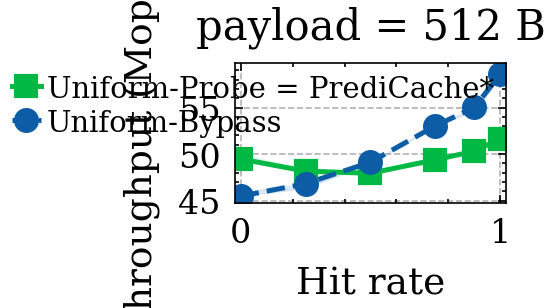

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p512.png and .pdf


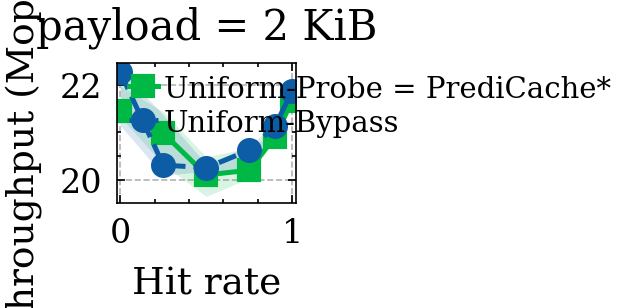

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p2k.png and .pdf


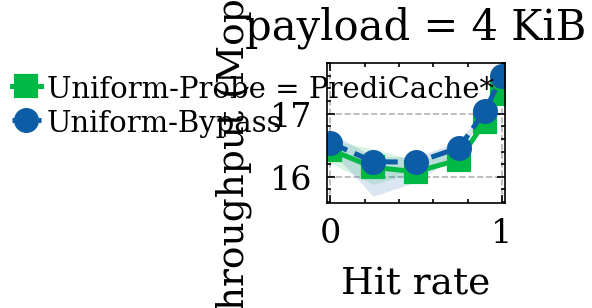

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p4k.png and .pdf


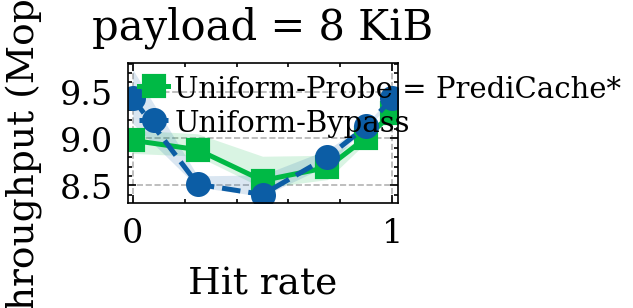

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p8k.png and .pdf


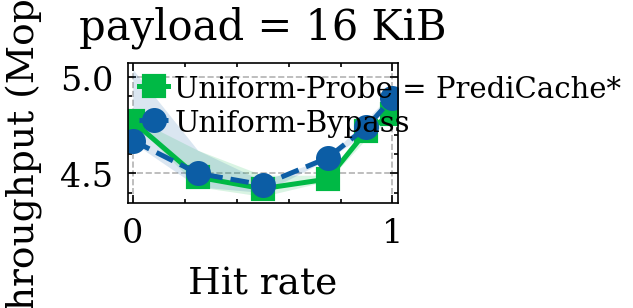

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p16k.png and .pdf


In [33]:
for payload in payloads:
    fig, ax = plt.subplots()
    draw_throughput_panel(ax, payload, show_legend=True)
    ax.set_title(title_for(payload), fontsize=10)
    fig.tight_layout()
    tag = file_tag(payload)
    fig.savefig(OUTDIR / f'prefer_sweep_{tag}.png', dpi=160)
    fig.savefig(OUTDIR / f'prefer_sweep_{tag}.pdf')
    plt.show()
    print(f'  wrote {OUTDIR / f"prefer_sweep_{tag}.png"} and .pdf')

## Throughput — combined grid (skipped when only one payload)

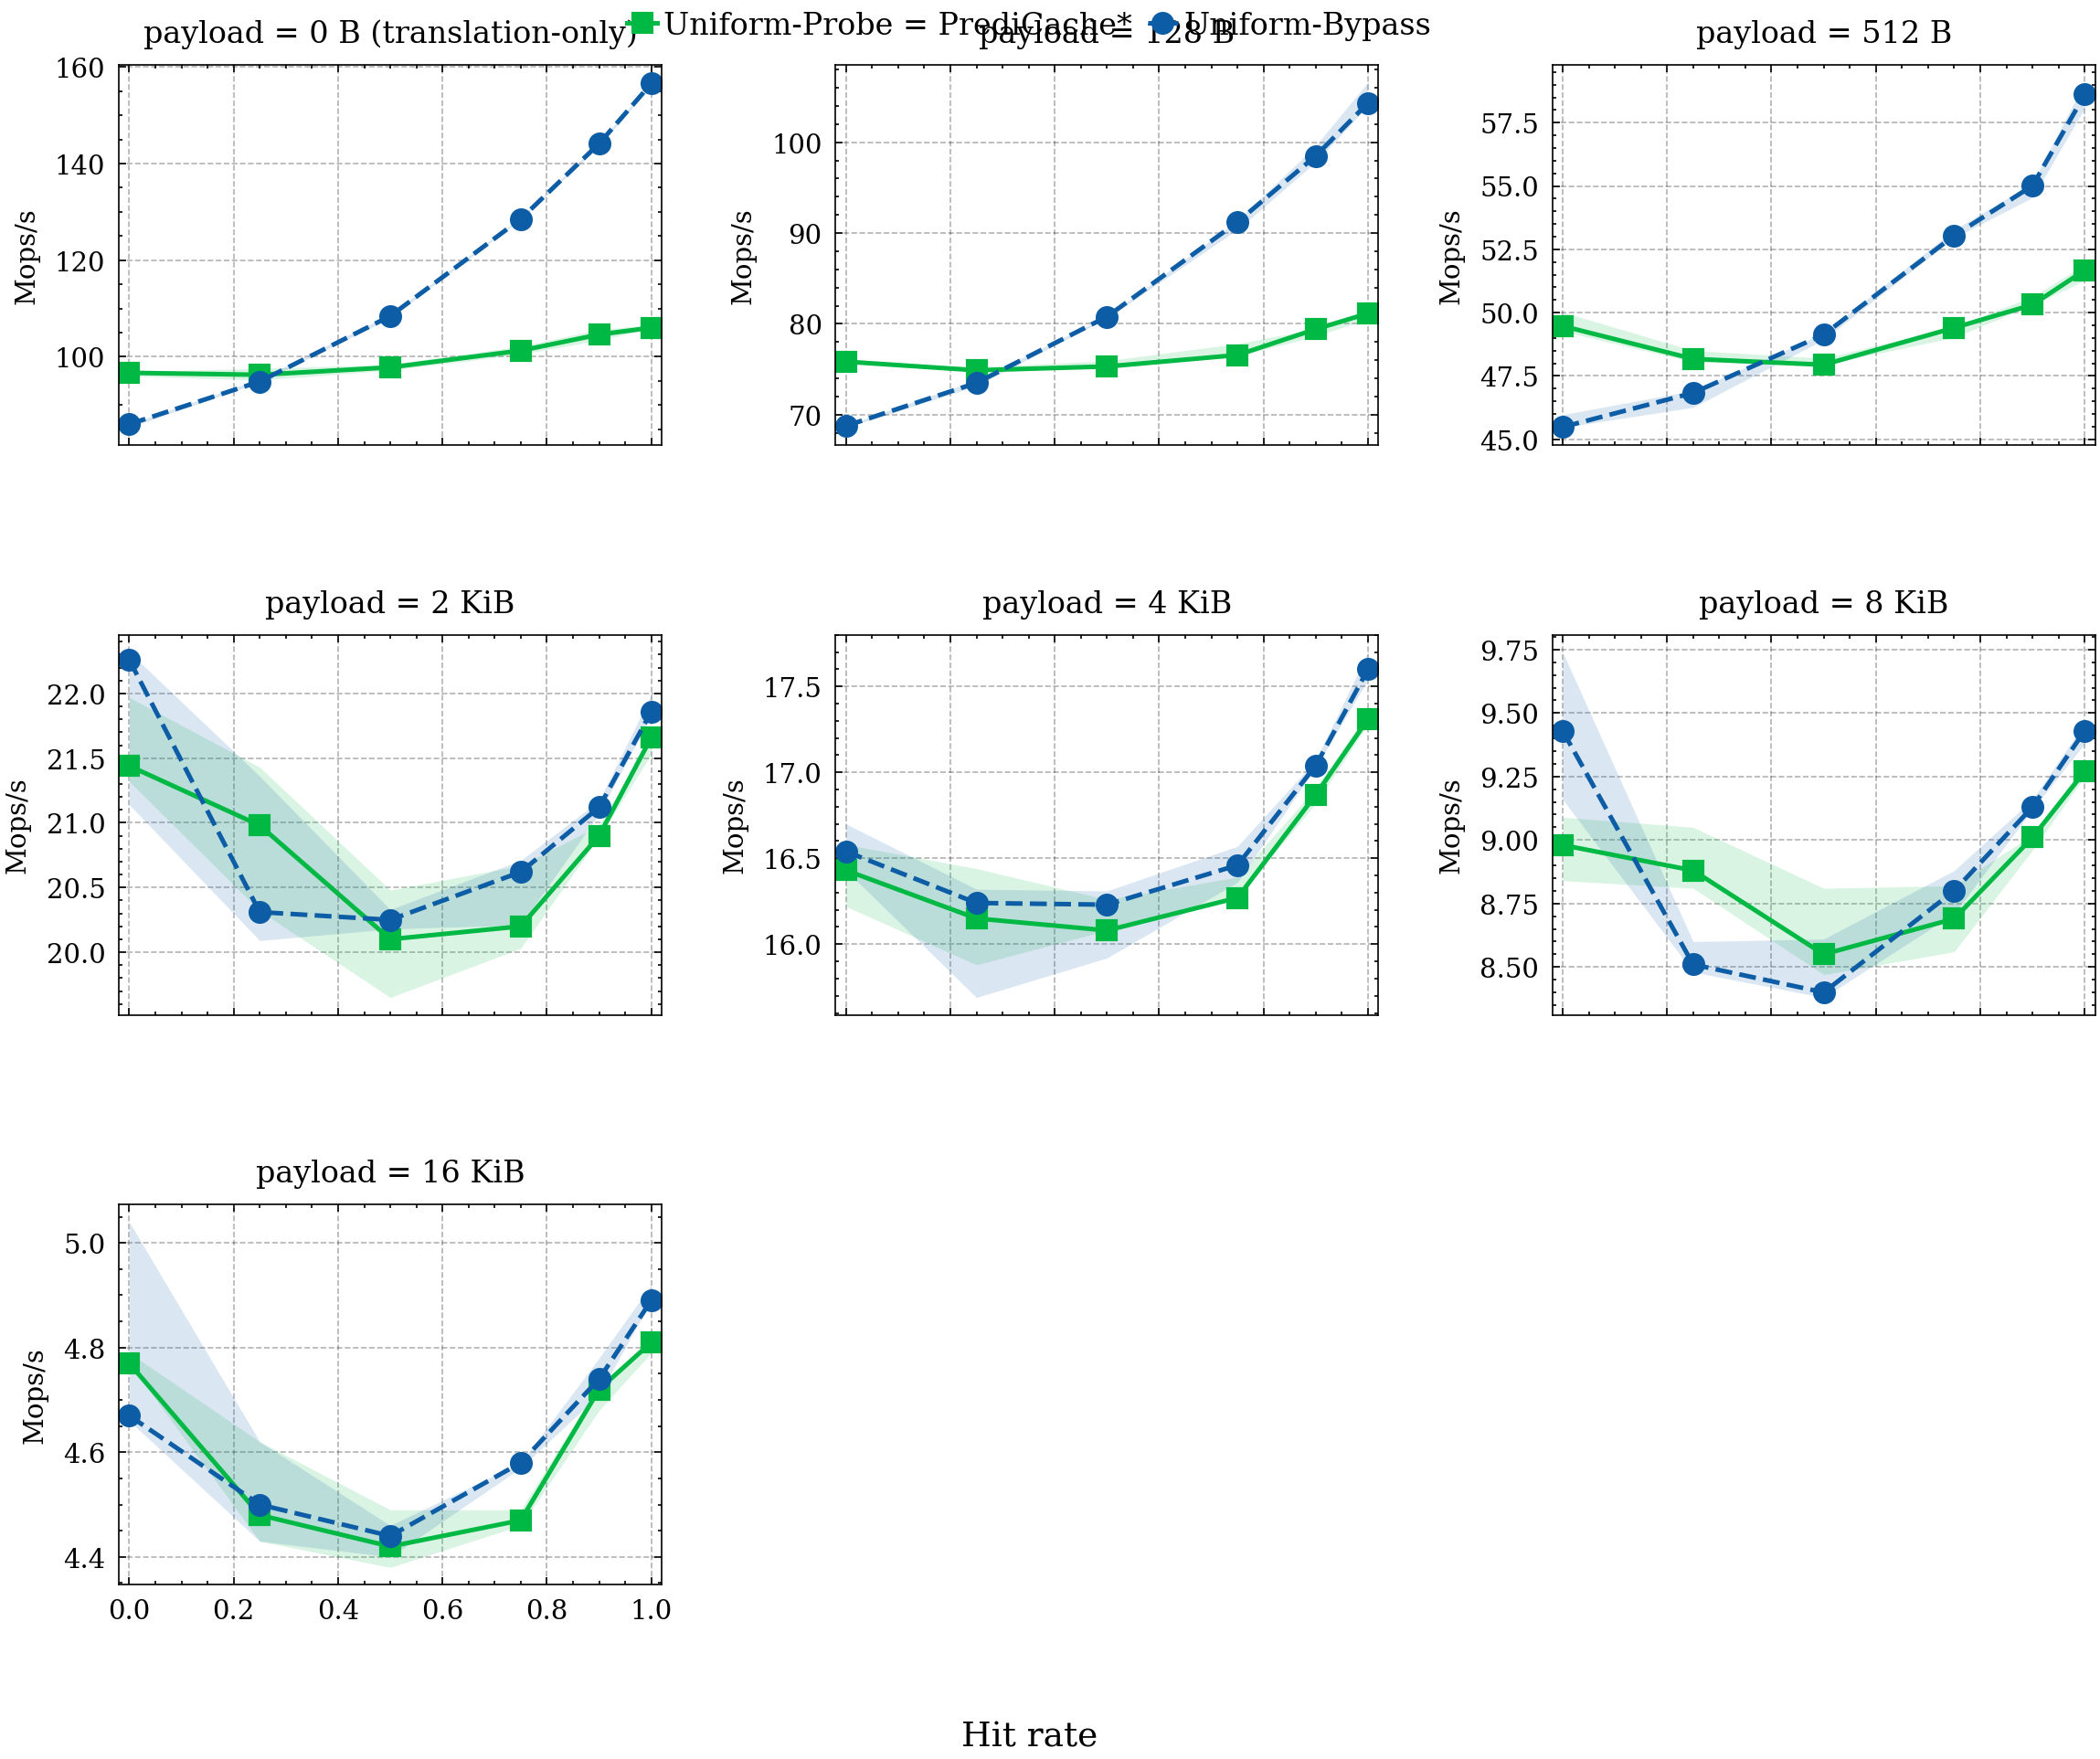

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep.png and .pdf (grid)


In [34]:
if len(payloads) > 1:
    ncols = min(3, len(payloads))
    nrows = (len(payloads) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(2.7 * ncols, 2.2 * nrows),
        sharex=True,
    )
    axes_list = (
        [axes] if len(payloads) == 1
        else (axes.flatten() if hasattr(axes, 'flatten') else list(axes))
    )
    for ax in axes_list[len(payloads):]:
        ax.axis('off')
    for i, payload in enumerate(payloads):
        ax = axes_list[i]
        draw_throughput_panel(ax, payload, show_legend=False)
        ax.set_title(title_for(payload), fontsize=8)
        ax.set_ylabel('Mops/s', fontsize=7)
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
    handles, labels = axes_list[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center', ncol=2,
        bbox_to_anchor=(0.5, 0.99),
        fontsize=8, frameon=False,
    )
    fig.supxlabel('Hit rate', fontsize=9, y=0.02)
    fig.subplots_adjust(
        top=1.0 - 0.14 / nrows, hspace=0.50, wspace=0.32,
        left=0.09, right=0.98, bottom=0.10 + 0.04 / nrows,
    )
    fig.savefig(OUTDIR / 'prefer_sweep.png', dpi=160)
    fig.savefig(OUTDIR / 'prefer_sweep.pdf')
    plt.show()
    print(f'  wrote {OUTDIR / "prefer_sweep.png"} and .pdf (grid)')
else:
    print('only one payload in the run — skipping the grid figure')

## Speedup — one stand-alone figure per payload

Single line per panel: `Uniform-Bypass median Mops/s ÷ Uniform-Probe median Mops/s`. Dashed `y = 1` line is the crossover (above ⇒ bypass wins).

Files: `prefer_sweep_p<tag>_speedup.{png,pdf}`.

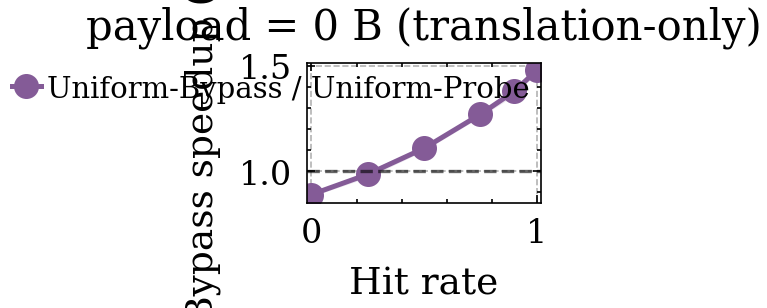

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p0_speedup.png and .pdf


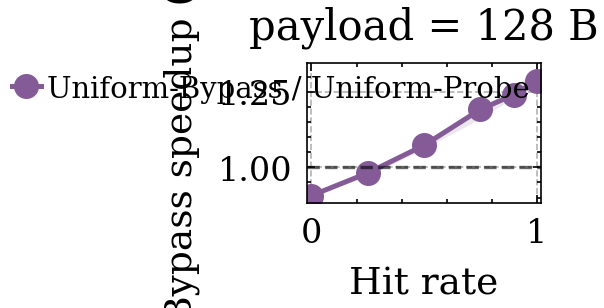

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p128_speedup.png and .pdf


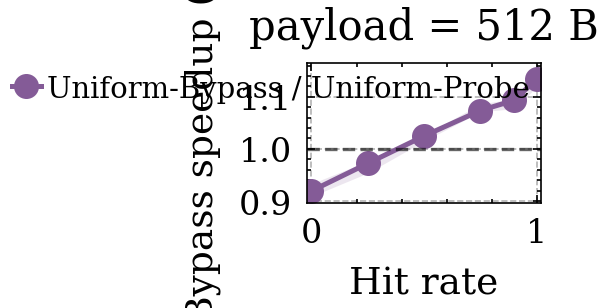

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p512_speedup.png and .pdf


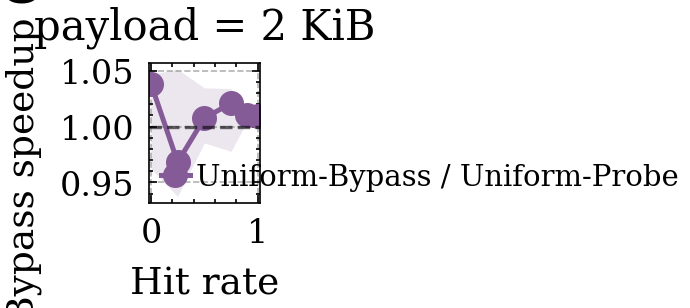

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p2k_speedup.png and .pdf


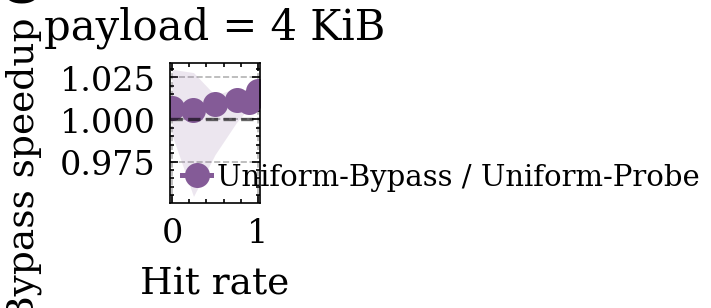

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p4k_speedup.png and .pdf


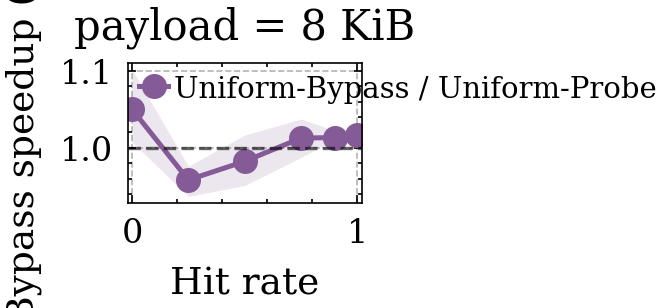

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p8k_speedup.png and .pdf


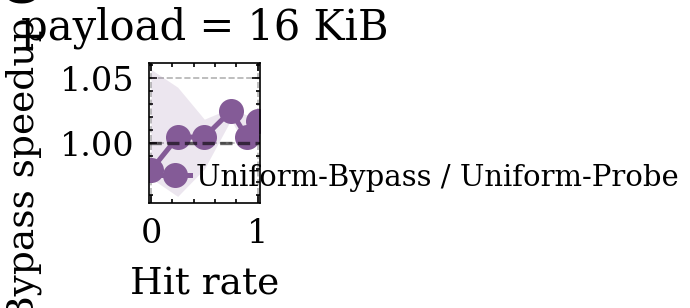

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_p16k_speedup.png and .pdf


In [35]:
for payload in payloads:
    fig, ax = plt.subplots()
    draw_speedup_panel(ax, payload, show_legend=True)
    ax.set_title(title_for(payload), fontsize=10)
    fig.tight_layout()
    tag = file_tag(payload)
    fig.savefig(OUTDIR / f'prefer_sweep_{tag}_speedup.png', dpi=160)
    fig.savefig(OUTDIR / f'prefer_sweep_{tag}_speedup.pdf')
    plt.show()
    print(f'  wrote {OUTDIR / f"prefer_sweep_{tag}_speedup.png"} and .pdf')

## Speedup — combined grid (skipped when only one payload)

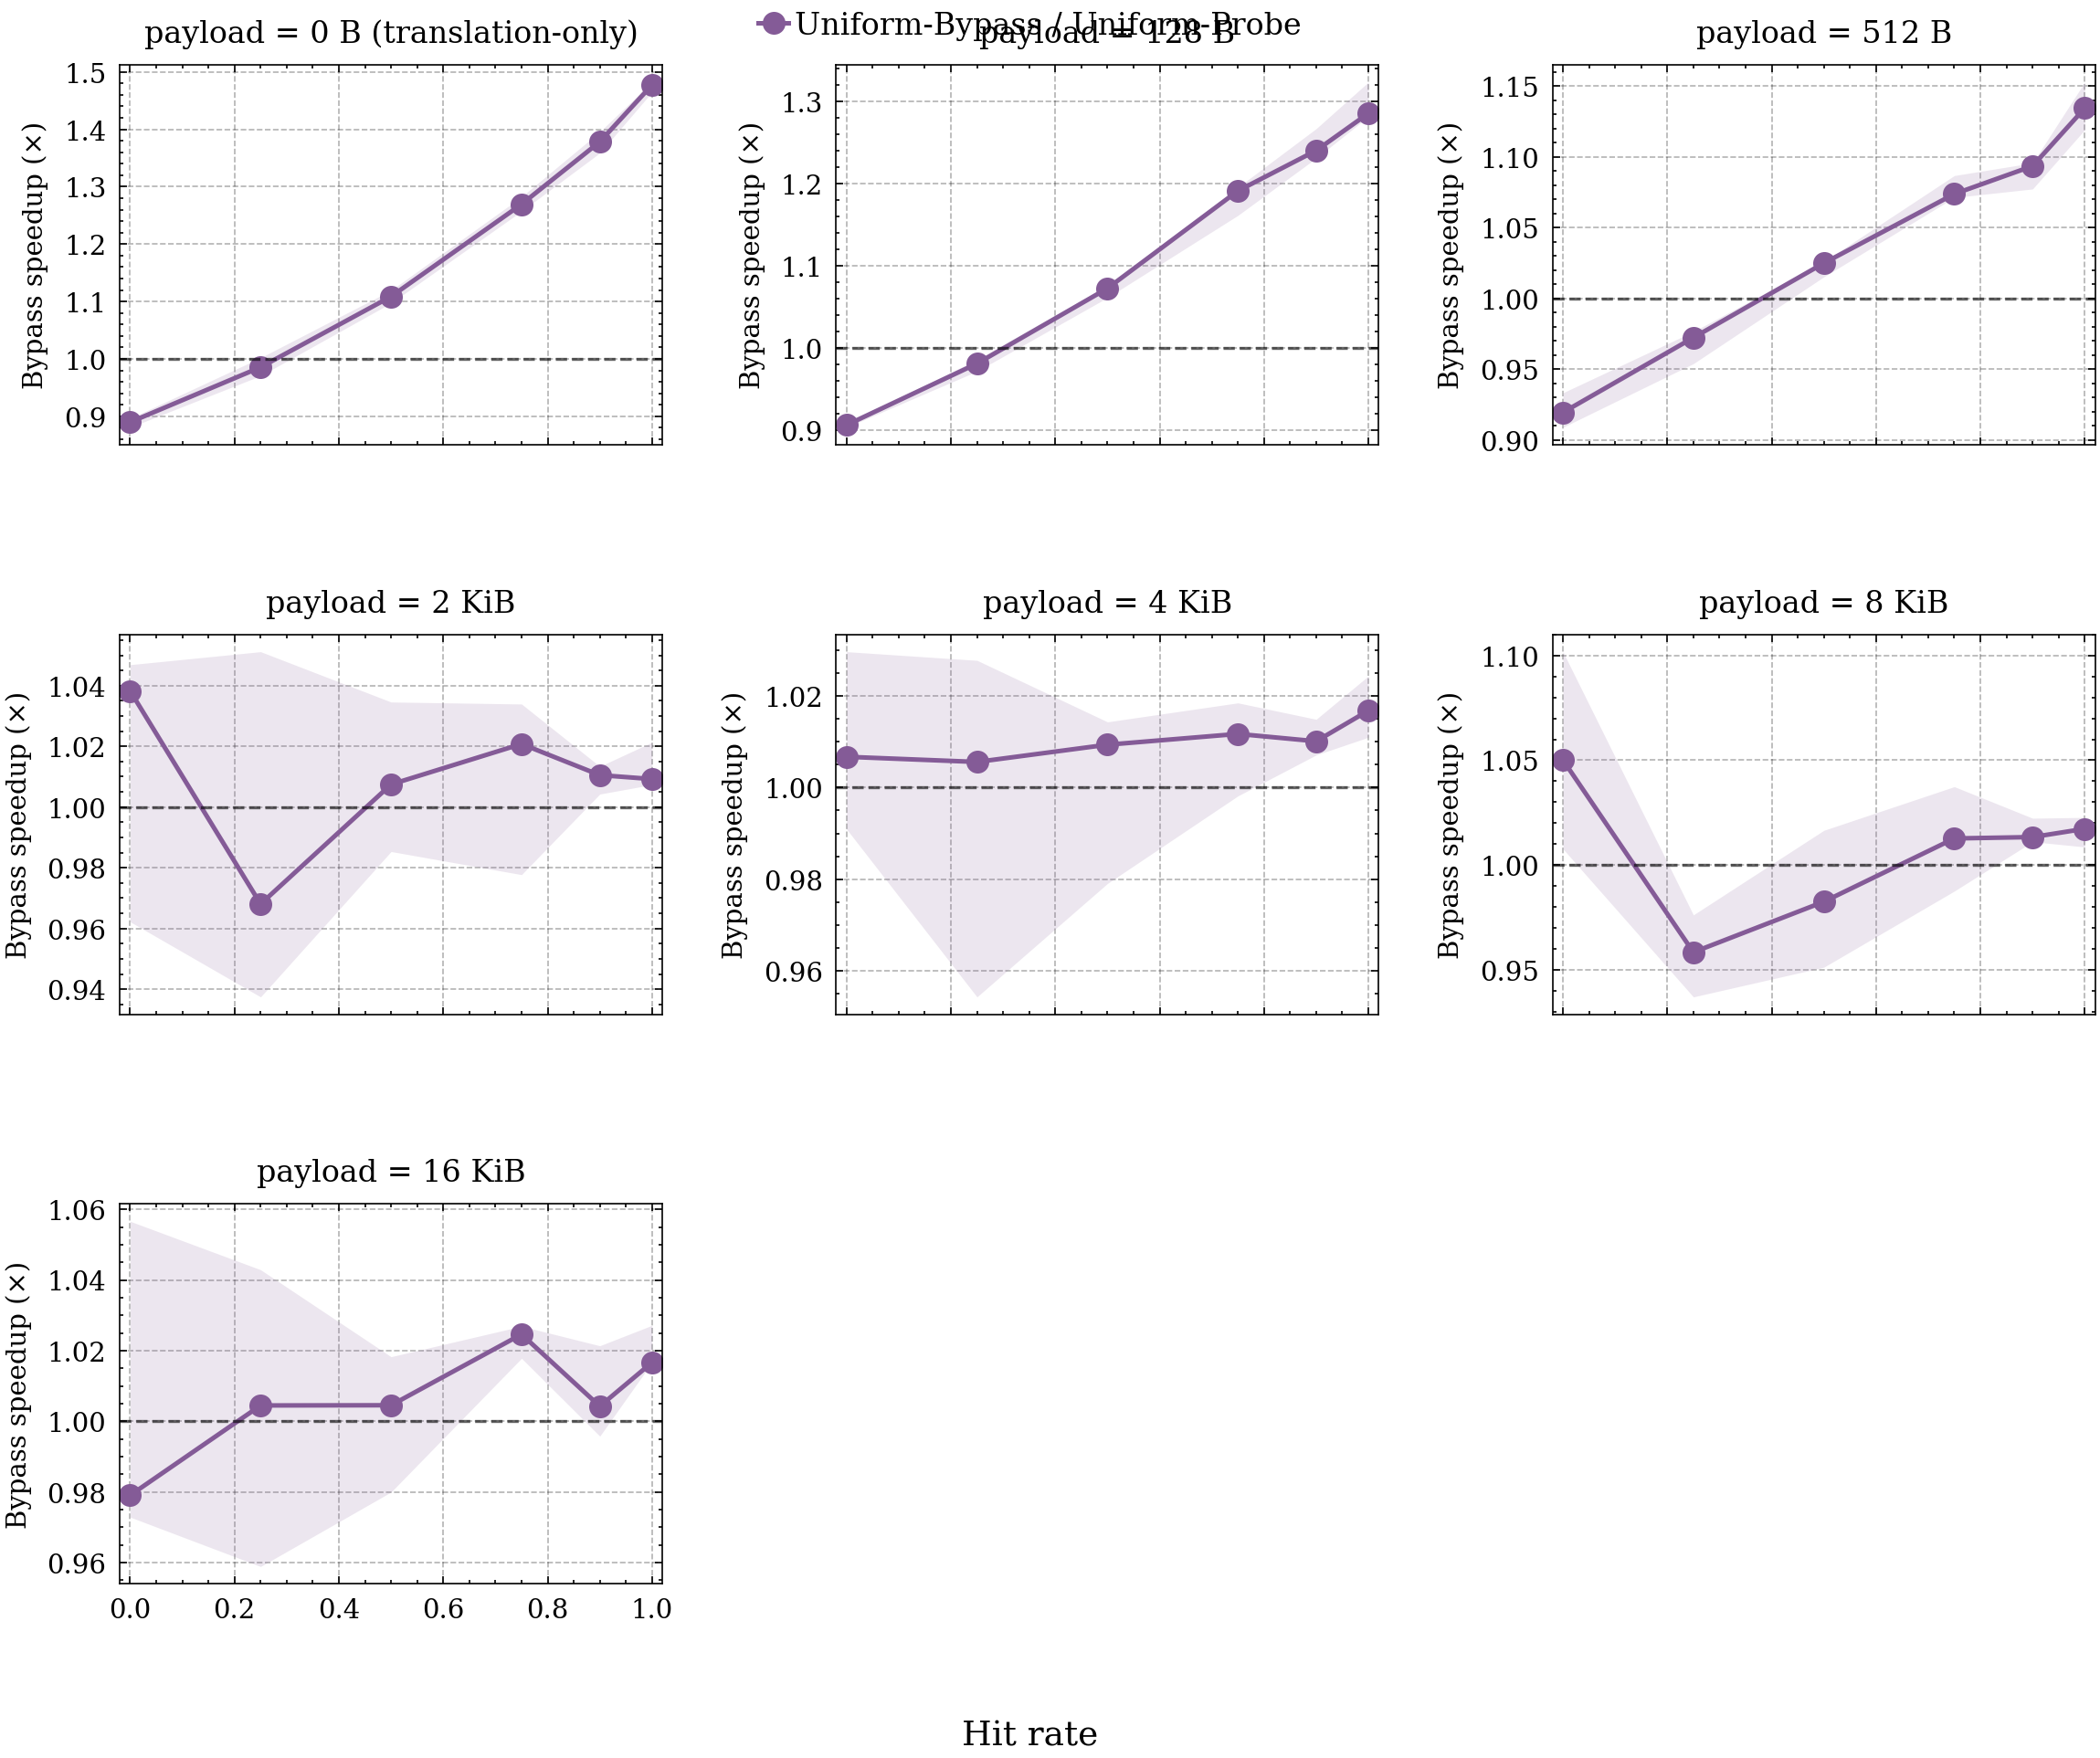

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_speedup.png and .pdf (grid)


In [36]:
if len(payloads) > 1:
    ncols = min(3, len(payloads))
    nrows = (len(payloads) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(2.7 * ncols, 2.2 * nrows),
        sharex=True,
    )
    axes_list = (
        [axes] if len(payloads) == 1
        else (axes.flatten() if hasattr(axes, 'flatten') else list(axes))
    )
    for ax in axes_list[len(payloads):]:
        ax.axis('off')
    for i, payload in enumerate(payloads):
        ax = axes_list[i]
        draw_speedup_panel(ax, payload, show_legend=False)
        ax.set_title(title_for(payload), fontsize=8)
        ax.set_ylabel('Bypass speedup (×)', fontsize=7)
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
    handles, labels = axes_list[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center', ncol=1,
        bbox_to_anchor=(0.5, 0.99),
        fontsize=8, frameon=False,
    )
    fig.supxlabel('Hit rate', fontsize=9, y=0.02)
    fig.subplots_adjust(
        top=1.0 - 0.14 / nrows, hspace=0.50, wspace=0.32,
        left=0.09, right=0.98, bottom=0.10 + 0.04 / nrows,
    )
    fig.savefig(OUTDIR / 'prefer_sweep_speedup.png', dpi=160)
    fig.savefig(OUTDIR / 'prefer_sweep_speedup.pdf')
    plt.show()
    print(f'  wrote {OUTDIR / "prefer_sweep_speedup.png"} and .pdf (grid)')
else:
    print('only one payload in the run — skipping the grid speedup figure')

## Speedup overlay — selected payloads on one axes

Single figure: one line per payload (no variance bands). Defaults to `0, 512, 4096, 16384`, edit `OVERLAY_PAYLOADS` to change. Output: `prefer_sweep_speedup_overlay.{png,pdf}`.

  wrote /mnt/nvme1/rotaki/LIPAH/dbspektrum_paper/results/prefer_merged_20260520_204305/prefer_sweep_speedup_overlay.png and .pdf


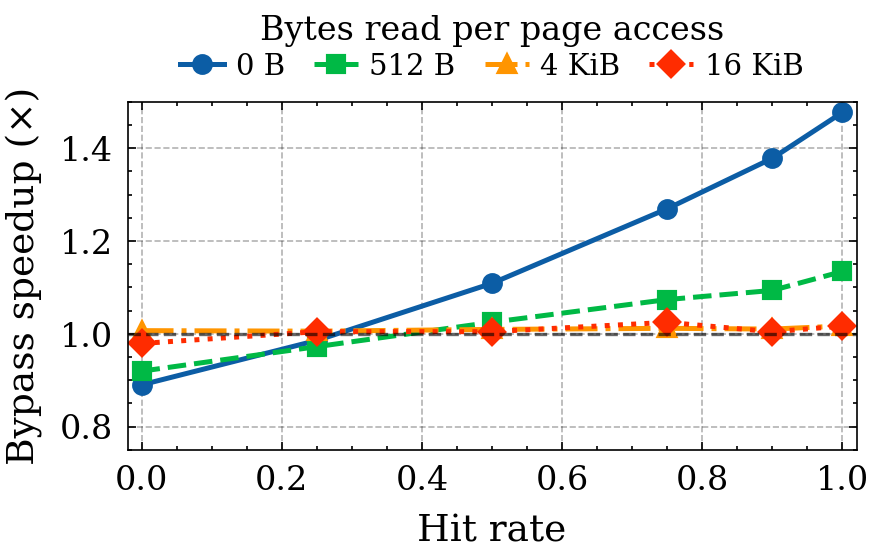

In [48]:
OVERLAY_PAYLOADS = [0, 512, 4096, 16384]
OVERLAY_PALETTE  = ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00']
OVERLAY_MARKERS  = ['o', 's', '^', 'D']

def overlay_label(payload):
    if payload >= 1024 and payload % 1024 == 0:
        return f'{payload // 1024} KiB'
    return f'{payload} B'

fig, ax = plt.subplots(figsize=(3.0, 2.0))
available = set(payloads)
drawn = 0
for p, color, mk in zip(OVERLAY_PAYLOADS, OVERLAY_PALETTE, OVERLAY_MARKERS):
    if p not in available:
        print(f'  skipping {p} (not in this run)')
        continue
    sub = speedup[speedup.payload == p].sort_values('prefer_prob')
    ax.plot(
        sub.prefer_prob, sub['median'],
        label=overlay_label(p), color=color, marker=mk,
        markersize=4, linewidth=1.2,
    )
    drawn += 1
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Hit rate', fontsize=9)
ax.set_ylabel('Bypass speedup (×)', fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.75, 1.5)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=8)
# Legend above the axes, horizontal, no frame. `bbox_to_anchor` is in
# axes-fraction coords (loc='lower center' anchored at y=1.02 puts the
# legend just above the top spine).
ax.legend(
    title='Bytes read per page access',
    loc='lower center', bbox_to_anchor=(0.5, 1.02),
    ncol=drawn if drawn else 1,
    fontsize=7, title_fontsize=8, frameon=False,
    handlelength=1.5, handletextpad=0.4,
    borderpad=0.3, columnspacing=1.0,
)
fig.subplots_adjust(left=0.16, right=0.97, top=0.80, bottom=0.22)
if drawn:
    fig.savefig(OUTDIR / 'prefer_sweep_speedup_overlay.png', dpi=330)
    fig.savefig(OUTDIR / 'prefer_sweep_speedup_overlay.pdf')
    print(f'  wrote {OUTDIR / "prefer_sweep_speedup_overlay.png"} and .pdf')
plt.show()


## Quick sanity table

Per-payload median throughput at the bookends of the hit-rate sweep, plus the implied bypass speedup.

In [38]:
snap = (
    g[g.prefer_prob.isin([df.prefer_prob.min(), df.prefer_prob.max()])]
      .pivot_table(index=['payload', 'variant'], columns='prefer_prob',
                   values='median')
      .round(2)
)
snap

prefer_prob        0.0     1.0
payload variant               
0       always   96.66  106.01
        bypass   86.01  156.60
128     always   75.83   81.15
        bypass   68.75  104.34
512     always   49.47   51.67
        bypass   45.48   58.61
2048    always   21.44   21.66
        bypass   22.26   21.86
4096    always   16.43   17.31
        bypass   16.54   17.60
8192    always    8.98    9.27
        bypass    9.43    9.43
16384   always    4.77    4.81
        bypass    4.67    4.89

In [39]:
speedup_snap = (
    speedup[speedup.prefer_prob.isin([df.prefer_prob.min(), df.prefer_prob.max()])]
      .pivot_table(index='payload', columns='prefer_prob', values='median')
      .round(2)
)
speedup_snap.columns = [f'speedup @ hit_rate={c}' for c in speedup_snap.columns]
speedup_snap

,speedup @ hit_rate=0.0,speedup @ hit_rate=1.0
payload,,
0,0.89,1.48
128,0.91,1.29
512,0.92,1.13
2048,1.04,1.01
4096,1.01,1.02
8192,1.05,1.02
16384,0.98,1.02
